**BLI validation for low-throughput, high-throughput, and predicted values for Omi32 and germline binding affinities to Wuhan, BA.1, and BA.4 spike RBD (presented in Supplemental Figure 1e-g from Tharp et al, 2026**

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.ticker as ticker
from matplotlib import rcParams
from scipy import stats
from scipy import odr
import numpy as np
from scipy import stats
import os

os.makedirs('images', exist_ok=True)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

In [7]:
germline_geno = '0000000000000'
omi_geno = '1111111111111'

# load high-throughput data for Omi32 and germline affinities to Wuhan, BA.1, and BA.4 spike RBD
ba1 = pd.read_csv('../../../BioPhy-Seq_measurements/high-throughput_measurements/results_Omi-32/cleaned_datasets/affinity/ba1_affinity_cleaned.csv')
ba1['geno']=ba1['geno'].astype('string').str.zfill(13)
ba4 = pd.read_csv('../../../BioPhy-Seq_measurements/high-throughput_measurements/results_Omi-32/cleaned_datasets/affinity/ba4_affinity_cleaned.csv')
ba4['geno']=ba4['geno'].astype('string').str.zfill(13)
wuhan = pd.read_csv('../../../BioPhy-Seq_measurements/high-throughput_measurements/results_Omi-32/cleaned_datasets/affinity/wuhan_affinity_cleaned.csv')
wuhan['geno']=wuhan['geno'].astype('string').str.zfill(13)

germ_ba1_mean = ba1[ba1['geno'] == germline_geno]['ba1_log10Kd_mean'].values[0]
germ_ba1_sem = ba1[ba1['geno'] == germline_geno]['ba1_log10Kd_sem'].values[0]
germ_ba4_mean = ba4[ba4['geno'] == germline_geno]['ba4_log10Kd_mean'].values[0]
germ_ba4_sem = ba4[ba4['geno'] == germline_geno]['ba4_log10Kd_sem'].values[0]
germ_wuhan_mean = wuhan[wuhan['geno'] == germline_geno]['wuhan_log10Kd_mean'].values[0]
germ_wuhan_sem = wuhan[wuhan['geno'] == germline_geno]['wuhan_log10Kd_sem'].values[0]
omi_ba1_mean = ba1[ba1['geno'] == omi_geno]['ba1_log10Kd_mean'].values[0]
omi_ba1_sem = ba1[ba1['geno'] == omi_geno]['ba1_log10Kd_sem'].values[0]
omi_ba4_mean = ba4[ba4['geno'] == omi_geno]['ba4_log10Kd_mean'].values[0]
omi_ba4_sem = ba4[ba4['geno'] == omi_geno]['ba4_log10Kd_sem'].values[0]
omi_wuhan_mean = wuhan[wuhan['geno'] == omi_geno]['wuhan_log10Kd_mean'].values[0]
omi_wuhan_sem = wuhan[wuhan['geno'] == omi_geno]['wuhan_log10Kd_sem'].values[0]

ht_means = [germ_ba1_mean, germ_ba4_mean, germ_wuhan_mean, omi_ba1_mean, omi_ba4_mean, omi_wuhan_mean]
ht_sems = [germ_ba1_sem, germ_ba4_sem, germ_wuhan_sem, omi_ba1_sem, omi_ba4_sem, omi_wuhan_sem]

# load predicted values for Omi32 and germline affinities to Wuhan, BA.1, and BA.4 spike RBD
wuhan_p = pd.read_csv('../../../epistasis_inference/linear_interaction_models/wuhan/reference-based/predicted_phenotypes/wuhan_raw_2order_full_biochem_predictions.csv')
wuhan_p['geno'] = wuhan_p['geno'].astype('str').str.zfill(13)
wuhan_p.rename(columns={'predicted_phenotype':'w_kd_mean_p','prediction_se':'w_kd_sem_p'}, inplace=True)

ba1_p = pd.read_csv('../../../epistasis_inference/linear_interaction_models/ba1/reference-based/predicted_phenotypes/ba1_raw_3order_full_biochem_predictions.csv')
ba1_p['geno'] = ba1_p['geno'].astype('str').str.zfill(13)
ba1_p.rename(columns={'predicted_phenotype':'ba1_kd_mean_p','prediction_se':'ba1_kd_sem_p'}, inplace=True)

ba4_p = pd.read_csv('../../../epistasis_inference/linear_interaction_models/ba4/reference-based/predicted_phenotypes/ba4_raw_3order_full_biochem_predictions.csv')
ba4_p['geno'] = ba4_p['geno'].astype('str').str.zfill(13)
ba4_p.rename(columns={'predicted_phenotype':'ba4_kd_mean_p','prediction_se':'ba4_kd_sem_p'}, inplace=True)

germ_ba1_p_mean = ba1_p[ba1_p['geno'] == germline_geno]['ba1_kd_mean_p'].values[0]
germ_ba1_p_sem = ba1_p[ba1_p['geno'] == germline_geno]['ba1_kd_sem_p'].values[0]
germ_ba4_p_mean = ba4_p[ba4_p['geno'] == germline_geno]['ba4_kd_mean_p'].values[0]
germ_ba4_p_sem = ba4_p[ba4_p['geno'] == germline_geno]['ba4_kd_sem_p'].values[0]
germ_wuhan_p_mean = wuhan_p[wuhan_p['geno'] == germline_geno]['w_kd_mean_p'].values[0]
germ_wuhan_p_sem = wuhan_p[wuhan_p['geno'] == germline_geno]['w_kd_sem_p'].values[0]
omi_ba1_p_mean = ba1_p[ba1_p['geno'] == omi_geno]['ba1_kd_mean_p'].values[0]
omi_ba1_p_sem = ba1_p[ba1_p['geno'] == omi_geno]['ba1_kd_sem_p'].values[0]
omi_ba4_p_mean = ba4_p[ba4_p['geno'] == omi_geno]['ba4_kd_mean_p'].values[0]
omi_ba4_p_sem = ba4_p[ba4_p['geno'] == omi_geno]['ba4_kd_sem_p'].values[0]
omi_wuhan_p_mean = wuhan_p[wuhan_p['geno'] == omi_geno]['w_kd_mean_p'].values[0]
omi_wuhan_p_sem = wuhan_p[wuhan_p['geno'] == omi_geno]['w_kd_sem_p'].values[0]

pred_means = [germ_ba1_p_mean, germ_ba4_p_mean, germ_wuhan_p_mean, omi_ba1_p_mean, omi_ba4_p_mean, omi_wuhan_p_mean]
pred_sems = [germ_ba1_p_sem, germ_ba4_p_sem, germ_wuhan_p_sem, omi_ba1_p_sem, omi_ba4_p_sem, omi_wuhan_p_sem]

# load low-throughput data for Omi32 and germline affinities to Wuhan, BA.1, and BA.4 spike RBD
lt_val = pd.read_csv('../../../BioPhy-Seq_measurements/isogenic_low-throughput_measurements/affinity/Omi32_low-throughput_affinities.csv')
lt_val['geno'] = lt_val['geno'].astype('int').astype('str').str.zfill(13)
print(lt_val)
germ_ba1_lt_mean = lt_val[lt_val['geno'] == germline_geno]['ba1_lt_mean'].values[0]
germ_ba1_lt_sem = lt_val[lt_val['geno'] == germline_geno]['ba1_lt_sem'].values[0]
germ_ba4_lt_mean = lt_val[lt_val['geno'] == germline_geno]['ba4_lt_mean'].values[0]
germ_ba4_lt_sem = lt_val[lt_val['geno'] == germline_geno]['ba4_lt_sem'].values[0]
germ_wuhan_lt_mean = lt_val[lt_val['geno'] == germline_geno]['wuhan_lt_mean'].values[0]
germ_wuhan_lt_sem = lt_val[lt_val['geno'] == germline_geno]['wuhan_lt_sem'].values[0]
omi_ba1_lt_mean = lt_val[lt_val['geno'] == omi_geno]['ba1_lt_mean'].values[0]
omi_ba1_lt_sem = lt_val[lt_val['geno'] == omi_geno]['ba1_lt_sem'].values[0]
omi_ba4_lt_mean = lt_val[lt_val['geno'] == omi_geno]['ba4_lt_mean'].values[0]
omi_ba4_lt_sem = lt_val[lt_val['geno'] == omi_geno]['ba4_lt_sem'].values[0]
omi_wuhan_lt_mean = lt_val[lt_val['geno'] == omi_geno]['wuhan_lt_mean'].values[0]
omi_wuhan_lt_sem = lt_val[lt_val['geno'] == omi_geno]['wuhan_lt_sem'].values[0]

lt_means = [germ_ba1_lt_mean, germ_ba4_lt_mean, germ_wuhan_lt_mean, omi_ba1_lt_mean, omi_ba4_lt_mean, omi_wuhan_lt_mean]
lt_sems = [germ_ba1_lt_sem, germ_ba4_lt_sem, germ_wuhan_lt_sem, omi_ba1_lt_sem, omi_ba4_lt_sem, omi_wuhan_lt_sem]

dfs = [ba1, ba4, wuhan]

# load BLI data for Omi32 and germline affinities to Wuhan, BA.1, and BA.4 spike RBD
bli = pd.read_csv('data/BLI_reps_omi-gl.csv')
bli['BLI_r1'] = -np.log10(bli['BLI_r1']/10**9)
bli['BLI_r2'] = -np.log10(bli['BLI_r2']/10**9)
bli['BLI_mean'] = bli[['BLI_r1', 'BLI_r2']].mean(axis=1,skipna=True)
bli['BLI_sem'] = bli[['BLI_r1', 'BLI_r2']].sem(axis=1,skipna=True)

bli['ht_mean'] = ht_means
bli['ht_sem'] = ht_sems
bli['pred_mean'] = pred_means
bli['pred_sem'] = pred_sems
bli['lt_mean'] = lt_means
bli['lt_sem'] = lt_sems

bli

  antibody           geno  wuhan_lt_mean  wuhan_lt_sem  ba1_lt_mean  \
0     2205  0100010100110           7.66          0.02         7.60   
1     6396  1100100011001           7.79          0.02          NaN   
2     5173  1010001000100            NaN           NaN         8.65   
3     6432  1100100111110            NaN           NaN         8.58   
4     4628  1001000100011            NaN           NaN         9.45   
5     4034  0111111001111           9.63          0.02          NaN   
6     5377  1010100010100           8.58          0.01          NaN   
7     5469  1010101110000            NaN           NaN          NaN   
8      omi  1111111111111           9.38          0.00         9.71   
9       gl  0000000000000           7.88          0.01         7.68   

   ba1_lt_sem  ba4_lt_mean  ba4_lt_sem  
0        0.02         7.13        0.13  
1         NaN         6.86        0.02  
2        0.00         7.84        0.01  
3        0.04          NaN         NaN  
4        0.10

,antibody,antigen,BLI_r1,BLI_r2,BLI_mean,BLI_sem,ht_mean,ht_sem,pred_mean,pred_sem,lt_mean,lt_sem
0,germline,ba1,6.254457,6.269783,6.262120,0.007663,7.000000,0.000000,7.398105,0.069789,7.68,0.01
1,germline,ba4,4.974244,4.997057,4.985650,0.011407,7.000000,0.000000,6.874339,0.059526,6.31,0.13
2,germline,wuhan,5.987163,NaN,5.987163,NaN,7.000000,0.000000,6.709208,0.043057,7.88,0.01
3,Omi32,ba1,7.692932,7.744486,7.718709,0.025777,9.779981,0.103582,9.846022,0.065216,9.71,0.07
4,Omi32,ba4,7.669181,7.666150,7.667665,0.001515,8.658467,0.382101,8.941384,0.058981,9.17,0.04
5,Omi32,wuhan,8.111315,NaN,8.111315,NaN,9.465425,0.251016,9.493937,0.041437,9.38,0.00


<>:47: SyntaxWarning: invalid escape sequence '\l'
<>:48: SyntaxWarning: invalid escape sequence '\l'
<>:47: SyntaxWarning: invalid escape sequence '\l'
<>:48: SyntaxWarning: invalid escape sequence '\l'
/var/folders/5c/ryv595916w771v24ng_5_tzw0000gn/T/ipykernel_7759/3728936822.py:47: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabel('BLI, $-\log_{10} K_{\mathrm{D}}$',     fontsize=8)
/var/folders/5c/ryv595916w771v24ng_5_tzw0000gn/T/ipykernel_7759/3728936822.py:48: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('BioPhy-Seq meas,\n$-\log_{10} K_{\mathrm{D}}$', fontsize=8)


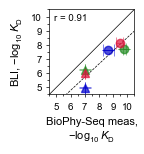

Pearson r = 0.9052,  p = 1.3048e-02


In [8]:
# high-throughput vs BLI correlation plot

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.bf'] = 'Arial:bold'

COLOR_WUHAN = "#DC143C"
COLOR_BA1   = "#228B22"
COLOR_BA4   = "#0000CD"

color_map  = {'wuhan': COLOR_WUHAN, 'ba1': COLOR_BA1, 'ba4': COLOR_BA4}
marker_map = {'germline': '^', 'Omi32': 'o'} 

CANVAS_W = 0.85   
CANVAS_H = 0.85

LEFT, RIGHT, BOTTOM, TOP = 0.55, 0.15, 0.50, 0.15
fig_w = LEFT + CANVAS_W + RIGHT
fig_h = BOTTOM + CANVAS_H + TOP

fig = plt.figure(figsize=(fig_w, fig_h))
ax  = fig.add_axes([LEFT/fig_w, BOTTOM/fig_h, CANVAS_W/fig_w, CANVAS_H/fig_h])

LIMS        = (4.5, 10.5)
MAJOR_TICKS = [5, 6, 7, 8, 9, 10]
MINOR_STEP  = 0.5   

ax.set_xlim(LIMS)
ax.set_ylim(LIMS)

ax.set_xticks(MAJOR_TICKS)
ax.set_yticks(MAJOR_TICKS)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(MINOR_STEP))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(MINOR_STEP))

ax.tick_params(axis='both', which='major', length=2,   width=0.5, labelsize=7,
               direction='out', top=False, right=False)
ax.tick_params(axis='both', which='minor', length=1.5, width=0.5, labelsize=0,
               direction='out', top=False, right=False)

for spine in ax.spines.values():
    spine.set_linewidth(0.5)

ax.set_ylabel('BLI, $-\log_{10} K_{\mathrm{D}}$',     fontsize=8)
ax.set_xlabel('BioPhy-Seq meas,\n$-\log_{10} K_{\mathrm{D}}$', fontsize=8)

ax.plot(LIMS, LIMS, '-k', linewidth=0.5, zorder=0)

for _, row in bli.iterrows():
    color  = color_map[row['antigen']]
    marker = marker_map[row['antibody']]

    x_err = row['ht_sem']  if pd.notna(row['ht_sem'])  else None
    y_err = row['BLI_sem'] if pd.notna(row['BLI_sem']) else None

    ax.errorbar(
        row['ht_mean'], row['BLI_mean'],
        xerr=x_err, yerr=y_err,
        fmt=marker,
        color=color,
        markersize=6,   
        linewidth=0.5,
        capsize=4,
        capthick=0.5,
        elinewidth=0.5,
        zorder=3,
        alpha=0.7
    )

x = bli['ht_mean'].values
y = bli['BLI_mean'].values

mask = np.isfinite(x) & np.isfinite(y)
x_fit = x[mask]
y_fit = y[mask]


r_value, p_value = stats.pearsonr(x_fit, y_fit)

def _f(B, x_):
    return B[0] * x_ + B[1]  

model = odr.Model(_f)
data = odr.RealData(x_fit, y_fit)  
odr_obj = odr.ODR(data, model, beta0=[1.0, 0.0])
out = odr_obj.run()
slope, intercept = out.beta

x_line = np.array(LIMS)
ax.plot(x_line, slope * x_line + intercept, '--k', linewidth=0.5, zorder=1)

ax.text(0.05, 0.95,
        f'r = {r_value:.2f}',
        transform=ax.transAxes,
        fontsize=7, va='top', ha='left',
        fontfamily='Arial')

plt.savefig('images/bli_ht_S_Fig_1e.png', dpi=2000, bbox_inches='tight',transparent=True)
plt.show()
print(f"Pearson r = {r_value:.4f},  p = {p_value:.4e}")

<>:46: SyntaxWarning: invalid escape sequence '\l'
<>:47: SyntaxWarning: invalid escape sequence '\l'
<>:93: SyntaxWarning: invalid escape sequence '\l'
<>:46: SyntaxWarning: invalid escape sequence '\l'
<>:47: SyntaxWarning: invalid escape sequence '\l'
<>:93: SyntaxWarning: invalid escape sequence '\l'
/var/folders/5c/ryv595916w771v24ng_5_tzw0000gn/T/ipykernel_7759/3859846844.py:46: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabel('BLI, $-\log_{10} K_{\mathrm{D}}$',     fontsize=8)
/var/folders/5c/ryv595916w771v24ng_5_tzw0000gn/T/ipykernel_7759/3859846844.py:47: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('Biophy-seq meas,\n$-\log_{10} K_{\mathrm{D}}$', fontsize=8)
/var/folders/5c/ryv595916w771v24ng_5_tzw0000gn/T/ipykernel_7759/3859846844.py:93: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('low-throughput meas,\n$-\log_{10} K_{\mathrm{D}}$', fontsize=8)


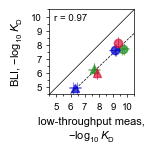

Pearson r = 0.9726,  p = 1.1184e-03


In [9]:
# low-throughput vs BLI correlation plot
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.bf'] = 'Arial:bold'

COLOR_WUHAN = "#DC143C"
COLOR_BA1   = "#228B22"
COLOR_BA4   = "#0000CD"

color_map  = {'wuhan': COLOR_WUHAN, 'ba1': COLOR_BA1, 'ba4': COLOR_BA4}
marker_map = {'germline': '^', 'Omi32': 'o'}  

CANVAS_W = 0.85   
CANVAS_H = 0.85

LEFT, RIGHT, BOTTOM, TOP = 0.55, 0.15, 0.50, 0.15
fig_w = LEFT + CANVAS_W + RIGHT
fig_h = BOTTOM + CANVAS_H + TOP

fig = plt.figure(figsize=(fig_w, fig_h))
ax  = fig.add_axes([LEFT/fig_w, BOTTOM/fig_h, CANVAS_W/fig_w, CANVAS_H/fig_h])

LIMS        = (4.5, 10.5)
MAJOR_TICKS = [5, 6, 7, 8, 9, 10]
MINOR_STEP  = 0.5   

ax.set_xlim(LIMS)
ax.set_ylim(LIMS)

ax.set_xticks(MAJOR_TICKS)
ax.set_yticks(MAJOR_TICKS)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(MINOR_STEP))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(MINOR_STEP))

ax.tick_params(axis='both', which='major', length=2,   width=0.5, labelsize=7,
               direction='out', top=False, right=False)
ax.tick_params(axis='both', which='minor', length=1.5, width=0.5, labelsize=0,
               direction='out', top=False, right=False)

for spine in ax.spines.values():
    spine.set_linewidth(0.5)

ax.set_ylabel('BLI, $-\log_{10} K_{\mathrm{D}}$',     fontsize=8)
ax.set_xlabel('Biophy-seq meas,\n$-\log_{10} K_{\mathrm{D}}$', fontsize=8)

ax.plot(LIMS, LIMS, '-k', linewidth=0.5, zorder=0)

for _, row in bli.iterrows():
    color  = color_map[row['antigen']]
    marker = marker_map[row['antibody']]

    x_err = row['lt_sem']  if pd.notna(row['lt_sem'])  else None
    y_err = row['BLI_sem'] if pd.notna(row['BLI_sem']) else None

    ax.errorbar(
        row['lt_mean'], row['BLI_mean'],
        xerr=x_err, yerr=y_err,
        fmt=marker, color=color,
        markersize=6, linewidth=0.5,
        capsize=4, capthick=0.5, elinewidth=0.5,
        zorder=3,
        alpha=0.7
    )

x = bli['lt_mean'].values
y = bli['BLI_mean'].values

mask = np.isfinite(x) & np.isfinite(y)
x_fit = x[mask]
y_fit = y[mask]

r_value, p_value = stats.pearsonr(x_fit, y_fit)

def _f(B, x_):
    return B[0] * x_ + B[1]  

model = odr.Model(_f)
data = odr.RealData(x_fit, y_fit)  
odr_obj = odr.ODR(data, model, beta0=[1.0, 0.0])
out = odr_obj.run()
slope, intercept = out.beta

x_line = np.array(LIMS)
ax.plot(x_line, slope * x_line + intercept, '--k', linewidth=0.5, zorder=1)

ax.text(0.05, 0.95, f'r = {r_value:.2f}',
        transform=ax.transAxes, fontsize=7, va='top', ha='left',
        fontfamily='Arial')

ax.set_xlabel('low-throughput meas,\n$-\log_{10} K_{\mathrm{D}}$', fontsize=8)

plt.savefig('images/bli_lt_S_Fig_1g.png', dpi=2000, bbox_inches='tight', transparent=True)
plt.show()
print(f"Pearson r = {r_value:.4f},  p = {p_value:.4e}")

<>:47: SyntaxWarning: invalid escape sequence '\l'
<>:48: SyntaxWarning: invalid escape sequence '\l'
<>:94: SyntaxWarning: invalid escape sequence '\l'
<>:47: SyntaxWarning: invalid escape sequence '\l'
<>:48: SyntaxWarning: invalid escape sequence '\l'
<>:94: SyntaxWarning: invalid escape sequence '\l'
/var/folders/5c/ryv595916w771v24ng_5_tzw0000gn/T/ipykernel_7759/720736664.py:47: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabel('BLI, $-\log_{10} K_{\mathrm{D}}$', fontsize=8)
/var/folders/5c/ryv595916w771v24ng_5_tzw0000gn/T/ipykernel_7759/720736664.py:48: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('Biophy-seq meas,\n$-\log_{10} K_{\mathrm{D}}$', fontsize=8)
/var/folders/5c/ryv595916w771v24ng_5_tzw0000gn/T/ipykernel_7759/720736664.py:94: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('predicted phenotype,\n$-\log_{10} K_{\mathrm{D}}$', fontsize=8)


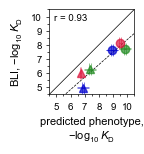

Pearson r = 0.9298,  p = 7.2237e-03


In [10]:
# predicted vs BLI correlation plot

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.bf'] = 'Arial:bold'

COLOR_WUHAN = "#DC143C"
COLOR_BA1   = "#228B22"
COLOR_BA4   = "#0000CD"

color_map  = {'wuhan': COLOR_WUHAN, 'ba1': COLOR_BA1, 'ba4': COLOR_BA4}
marker_map = {'germline': '^', 'Omi32': 'o'}  

CANVAS_W = 0.85   
CANVAS_H = 0.85

LEFT, RIGHT, BOTTOM, TOP = 0.55, 0.15, 0.50, 0.15
fig_w = LEFT + CANVAS_W + RIGHT
fig_h = BOTTOM + CANVAS_H + TOP

fig = plt.figure(figsize=(fig_w, fig_h))
ax  = fig.add_axes([LEFT/fig_w, BOTTOM/fig_h, CANVAS_W/fig_w, CANVAS_H/fig_h])

LIMS        = (4.5, 10.5)
MAJOR_TICKS = [5, 6, 7, 8, 9, 10]
MINOR_STEP  = 0.5

ax.set_xlim(LIMS)
ax.set_ylim(LIMS)

ax.set_xticks(MAJOR_TICKS)
ax.set_yticks(MAJOR_TICKS)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(MINOR_STEP))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(MINOR_STEP))

ax.tick_params(axis='both', which='major', length=2, width=0.5, labelsize=7,
               direction='out', top=False, right=False)
ax.tick_params(axis='both', which='minor', length=1.5, width=0.5, labelsize=0,
               direction='out', top=False, right=False)

for spine in ax.spines.values():
    spine.set_linewidth(0.5)

ax.set_ylabel('BLI, $-\log_{10} K_{\mathrm{D}}$', fontsize=8)
ax.set_xlabel('Biophy-seq meas,\n$-\log_{10} K_{\mathrm{D}}$', fontsize=8)

ax.plot(LIMS, LIMS, '-k', linewidth=0.5, zorder=0)

for _, row in bli.iterrows():
    color  = color_map[row['antigen']]
    marker = marker_map[row['antibody']]

    x_err = row['pred_sem'] if pd.notna(row['pred_sem']) else None
    y_err = row['BLI_sem']  if pd.notna(row['BLI_sem'])  else None

    ax.errorbar(
        row['pred_mean'], row['BLI_mean'],
        xerr=x_err, yerr=y_err,
        fmt=marker, color=color,
        markersize=6, linewidth=0.5,
        capsize=4, capthick=0.5, elinewidth=0.5,
        zorder=3,
        alpha=0.7
    )

x = bli['pred_mean'].values
y = bli['BLI_mean'].values

mask = np.isfinite(x) & np.isfinite(y)
x_fit = x[mask]
y_fit = y[mask]

r_value, p_value = stats.pearsonr(x_fit, y_fit)

def _f(B, x_):
    return B[0] * x_ + B[1]

model = odr.Model(_f)
data = odr.RealData(x_fit, y_fit)
odr_obj = odr.ODR(data, model, beta0=[1.0, 0.0])
out = odr_obj.run()
slope, intercept = out.beta

x_line = np.array(LIMS)
ax.plot(x_line, slope * x_line + intercept, '--k', linewidth=0.5, zorder=1)

ax.text(0.05, 0.95, f'r = {r_value:.2f}',
        transform=ax.transAxes, fontsize=7, va='top', ha='left',
        fontfamily='Arial')

ax.set_xlabel('predicted phenotype,\n$-\log_{10} K_{\mathrm{D}}$', fontsize=8)

plt.savefig('images/pred_bli_S_Fig_1f.png', dpi=2000, bbox_inches='tight', transparent=True)
plt.show()

print(f"Pearson r = {r_value:.4f},  p = {p_value:.4e}")